# Load Dataset

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
files = os.listdir()

print(files)

['.ipynb_checkpoints', 'Data Coverage File CSV.csv', 'Data Quality VODIM and Integrity File.csv', 'KPI definitions metric IDs.xlsx.xlsx', 'MHSDS Data_MarPerf_2026_v2.csv', 'MHSDS_Final_KPI_Table.csv', 'MHSDS_Source_Mapping.csv', 'outputs', 'RTT  waiting times.xlsx', 'Time_Series_data_Apr2025_Mar_Perf_2026_v2.csv', 'Time_Series_data_Apr_2016_MarPrf_2023.csv', 'Time_Series_data_Apr_2023_MarFinal_2024.csv', 'Time_Series_data_Apr_2024_Mar_2025_Final.csv', 'Untitled.ipynb']


In [3]:
import pandas as pd

# MAIN MHSDS FILE
mhsds = pd.read_csv(
    "MHSDS Data_MarPerf_2026_v2.csv",
    low_memory=False
)

# RTT FILE
rtt = pd.read_excel(
    "RTT  waiting times.xlsx"
)

# KPI MAPPING FILE
kpi_map = pd.read_excel(
    "KPI definitions metric IDs.xlsx.xlsx"
)

# TIME SERIES FILE
time_series = pd.read_csv(
    "Time_Series_data_Apr2025_Mar_Perf_2026_v2.csv",
    low_memory=False
)

print("All files loaded successfully")

All files loaded successfully


In [4]:
print(mhsds.shape)
print(mhsds.columns.tolist())

(764377, 11)
['REPORTING_PERIOD_START', 'REPORTING_PERIOD_END', 'STATUS', 'BREAKDOWN', 'PRIMARY_LEVEL', 'PRIMARY_LEVEL_DESCRIPTION', 'SECONDARY_LEVEL', 'SECONDARY_LEVEL_DESCRIPTION', 'MEASURE_ID', 'MEASURE_NAME', 'MEASURE_VALUE']


# View Available KPI Names

In [5]:
print(mhsds["MEASURE_NAME"].nunique())

mhsds["MEASURE_NAME"].drop_duplicates().tolist()[:200]

379


['Contacts in the RP with community mental health services for adult and older adults with severe mental illness',
 'Attended contacts in the RP with community mental health services for adult and older adults with severe mental illness',
 'Referrals starting in the RP to community mental health services for adult and older adults with severe mental illness',
 'People discharged from a referral in the RP from community mental health services for adult and older adults with severe mental illness',
 'Open referrals to community mental health services for adult and older adults with severe mental illness',
 'Contacts with perinatal MH team in the Reporting Period',
 'Care contacts by Attended / did not attend code',
 'Number of admissions to hospital in the reporting period',
 'Attended contacts with perinatal MH team in Reporting Period',
 'Attended contacts in the RP, 0 to 18, by consultation medium',
 'Attended contacts in the RP by consultation medium',
 'First attended contacts for r

# Required KPIs

In [6]:
keywords = [
    "bed",
    "contact",
    "crisis",
    "admission",
    "waiting",
    "rtt"
]

for key in keywords:
    
    print("\n")
    print("="*50)
    print("KEYWORD:", key.upper())
    print("="*50)
    
    temp = mhsds[
        mhsds["MEASURE_NAME"]
        .str.contains(key, case=False, na=False)
    ]
    
    print(
        temp["MEASURE_NAME"]
        .drop_duplicates()
        .tolist()[:50]
    )



KEYWORD: BED
['Bed days in RP', 'Under 16 bed days on adult wards in reporting period', 'Age 16 bed days on adult wards in reporting period', 'Age 17 bed days on adult wards in reporting period', 'Bed days less leave in RP', 'Number of discharges in the RP for people aged 18 and over from adult acute, older adult acute and PICU beds', 'Total bed days for discharges in the RP for people aged 18 and over from adult acute, older adult acute and PICU beds', 'Mean Length of stay for discharges in the RP for people aged 18 and over from adult acute, older adult acute and PICU beds', 'Number of discharges in the RP for people aged 18 and over from adult acute and PICU beds', 'Total bed days for discharges in the RP for people aged 18 and over from adult acute and PICU beds', 'Mean Length of stay for discharges in the RP for people aged 18 and over from adult acute and PICU beds', 'Number of discharges in the RP for people aged 18 and over from older adult acute beds', 'Total bed days for di

# Extract Beds KPI

In [7]:
beds = mhsds[
    mhsds["MEASURE_NAME"]
    .str.contains("bed", case=False, na=False)
]

print(beds.shape)

display(
    beds[
        [
            "MEASURE_ID",
            "MEASURE_NAME",
            "MEASURE_VALUE"
        ]
    ].head()
)

(20391, 11)


,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE
20270,MHS24,Bed days in RP,3915
20271,MHS24a,Under 16 bed days on adult wards in reporting ...,*
20272,MHS24b,Age 16 bed days on adult wards in reporting pe...,*
20273,MHS24c,Age 17 bed days on adult wards in reporting pe...,*
20274,MHS25,Bed days less leave in RP,3595


# Extract Contacts KPI

In [8]:
contacts = mhsds[
    mhsds["MEASURE_NAME"]
    .str.contains("contact", case=False, na=False)
]

print(contacts.shape)

display(
    contacts[
        [
            "MEASURE_ID",
            "MEASURE_NAME",
            "MEASURE_VALUE"
        ]
    ].head()
)

(174123, 11)


,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE
0,MHS29d,Contacts in the RP with community mental healt...,3150
1,MHS30f,Attended contacts in the RP with community men...,2260
5,MHS29d,Contacts in the RP with community mental healt...,2500
6,MHS30f,Attended contacts in the RP with community men...,1960
10,MHS29d,Contacts in the RP with community mental healt...,220


# Extract Crisis KPI

In [9]:
crisis = mhsds[
    mhsds["MEASURE_NAME"]
    .str.contains("crisis", case=False, na=False)
]

print(crisis.shape)

display(
    crisis[
        [
            "MEASURE_ID",
            "MEASURE_NAME",
            "MEASURE_VALUE"
        ]
    ].head()
)

(13594, 11)


,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE
20255,MHS19,People with a crisis plan in place at the end ...,15
20267,MHS23b,Open referrals to crisis resolution service or...,50
20280,MHS29b,Contacts with crisis resolution service or hom...,685
20285,MHS30b,Attended contacts with crisis resolution servi...,625
20360,MHS19,People with a crisis plan in place at the end ...,10


# Extract Admissions KPI

In [10]:
admissions = mhsds[
    mhsds["MEASURE_NAME"]
    .str.contains("admission", case=False, na=False)
]

print(admissions.shape)

display(
    admissions[
        [
            "MEASURE_ID",
            "MEASURE_NAME",
            "MEASURE_VALUE"
        ]
    ].head()
)

(27874, 11)


,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE
2632,MHS27a,Number of admissions to hospital in the report...,10
2633,MHS27a,Number of admissions to hospital in the report...,*
2634,MHS27a,Number of admissions to hospital in the report...,*
2635,MHS27a,Number of admissions to hospital in the report...,*
2636,MHS27a,Number of admissions to hospital in the report...,5


# Final KPI Aggregation

In [11]:
beds_value = pd.to_numeric(
    beds["MEASURE_VALUE"],
    errors="coerce"
).sum()

contacts_value = pd.to_numeric(
    contacts["MEASURE_VALUE"],
    errors="coerce"
).sum()

crisis_value = pd.to_numeric(
    crisis["MEASURE_VALUE"],
    errors="coerce"
).sum()

admissions_value = pd.to_numeric(
    admissions["MEASURE_VALUE"],
    errors="coerce"
).sum()

final_kpi = pd.DataFrame({

    "KPI": [
        "Beds",
        "Contacts",
        "Crisis Calls",
        "Admissions"
    ],

    "Value": [
        beds_value,
        contacts_value,
        crisis_value,
        admissions_value
    ]
})

display(final_kpi)

,KPI,Value
0,Beds,1.526307e+07
1,Contacts,1.954265e+08
2,Crisis Calls,2.125992e+06
3,Admissions,4.285240e+05


# CREATE BAR CHART

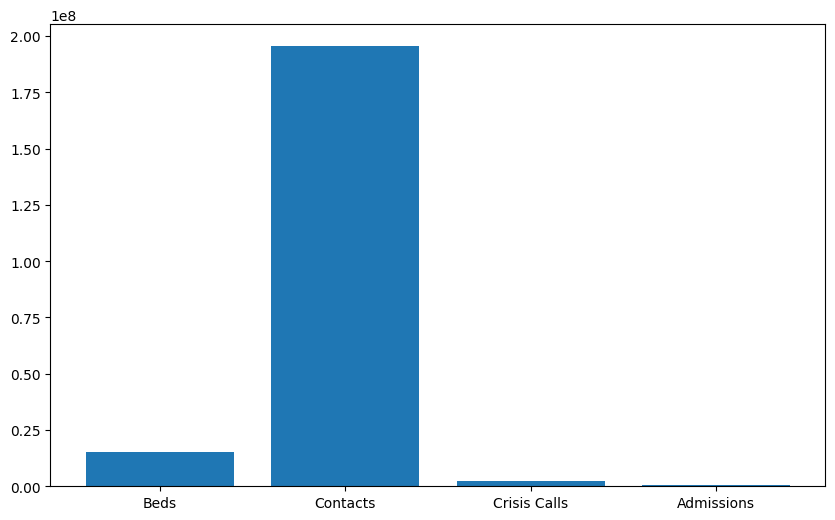

In [12]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
   final_kpi["KPI"],
    final_kpi["Value"]
)


# RTT 

In [15]:
rtt_file = "RTT  waiting times.xlsx"

In [16]:
xls = pd.ExcelFile(rtt_file)

print("Available Sheets:")
for sheet in xls.sheet_names:
    print(sheet)

Available Sheets:
Title sheet
Notes and definitions
Table 1a
Table 1b
Table 2a
Table 2b
Table 3a
Table 3b
Table 5a
Table 5b


# PREVIEW ALL SHEETS

In [17]:

for sheet in xls.sheet_names:
    
    print("\n" + "="*70)
    print("SHEET:", sheet)
    print("="*70)
    
    temp = pd.read_excel(
        rtt_file,
        sheet_name=sheet,
        header=None,
        nrows=12
    )
    
    display(temp)


SHEET: Title sheet


,0,1
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,Mental Health Services Monthly Statistics,NaN
8,Access and Waiting Times,NaN
9,"Data Tables, Performance January 2026 to March...",NaN



SHEET: Notes and definitions


,0
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,Return to Contents
8,Notes and definitions:
9,Data source: Mental Health Services Data Set (...



SHEET: Table 1a


...

,0,1,2,3,4,5,6,7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Return to Contents,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Table 3b: Open referrals for people with a sus...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,,NaN,NaN,NaN,NaN,NaN,NaN,NaN



SHEET: Table 5a


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Return to Contents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Table 5a: Referrals for people with suspected ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



SHEET: Table 5b


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Return to Contents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Table 5b: Referrals for people with suspected ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
possible_data_sheets = []

for sheet in xls.sheet_names:
    
    temp = pd.read_excel(
        rtt_file,
        sheet_name=sheet,
        header=None
    )
    
    if temp.shape[1] > 3 and temp.dropna(how="all").shape[0] > 5:
        possible_data_sheets.append(sheet)
        print("Possible Data Sheet:", sheet, temp.shape)

print("\nPossible data sheets:", possible_data_sheets)

Possible Data Sheet: Table 1a (488, 7)
Possible Data Sheet: Table 1b (131, 7)
Possible Data Sheet: Table 2a (490, 43)
Possible Data Sheet: Table 2b (136, 43)
Possible Data Sheet: Table 3a (489, 8)
Possible Data Sheet: Table 3b (134, 8)
Possible Data Sheet: Table 5a (490, 28)
Possible Data Sheet: Table 5b (135, 28)

Possible data sheets: ['Table 1a', 'Table 1b', 'Table 2a', 'Table 2b', 'Table 3a', 'Table 3b', 'Table 5a', 'Table 5b']


# FUNCTION: AUTO FIND HEADER ROW

In [19]:
def find_header_row(file, sheet):
    
    raw = pd.read_excel(
        file,
        sheet_name=sheet,
        header=None
    )
    
    keywords = [
        "provider",
        "organisation",
        "org",
        "ccg",
        "sub",
        "measure",
        "waiting",
        "wait",
        "referral",
        "rtt",
        "treatment",
        "count",
        "median",
        "mean",
        "weeks"
    ]
    
    best_row = 0
    best_score = -1
    
    for i in range(min(30, len(raw))):
        
        row_text = " ".join(
            raw.iloc[i]
            .astype(str)
            .str.lower()
            .tolist()
        )
        
        score = sum(1 for key in keywords if key in row_text)
        
        non_null = raw.iloc[i].notna().sum()
        
        total_score = score + non_null
        
        if total_score > best_score:
            best_score = total_score
            best_row = i
    
    return best_row

# LOAD ALL POSSIBLE RTT DATA SHEETS


In [20]:
rtt_tables = {}

for sheet in possible_data_sheets:
    
    header_row = find_header_row(rtt_file, sheet)
    
    temp = pd.read_excel(
        rtt_file,
        sheet_name=sheet,
        header=header_row
    )
    
    temp = temp.dropna(how="all")
    
    temp.columns = (
        temp.columns
        .astype(str)
        .str.strip()
        .str.replace("\n", " ")
        .str.replace(" ", "_")
        .str.replace("-", "_")
        .str.replace("/", "_")
    )
    
    rtt_tables[sheet] = temp
    
    print("\nLoaded Sheet:", sheet)
    print("Header Row:", header_row)
    print("Shape:", temp.shape)
    print("Columns:", temp.columns.tolist())
    display(temp.head())


Loaded Sheet: Table 1a
Header Row: 17
Shape: (467, 7)
Columns: ['AML01', 'Unnamed:_1', '1POINT_(NORTH_WEST)', 'Unnamed:_3', '70', '*', '*.1']


,AML01,Unnamed:_1,1POINT_(NORTH_WEST),Unnamed:_3,70,*,*.1
0,8K232,NaN,2BU SOMERSET,NaN,25,*,*
1,DRL,NaN,42ND STREET,NaN,685,*,*
2,D6Q3E,NaN,ABBI CLINIC,NaN,*,*,*
3,8HV73,NaN,ABL HEALTH,NaN,835,*,5
4,M1B6C,NaN,ABL HEALTH - SWINDON,NaN,720,*,15



Loaded Sheet: Table 1b
Header Row: 19
Shape: (108, 7)
Columns: ['D2P2L', 'Unnamed:_1', 'NHS_BLACK_COUNTRY_ICB___D2P2L', 'Unnamed:_3', '28400', '150', '155']


,D2P2L,Unnamed:_1,NHS_BLACK_COUNTRY_ICB___D2P2L,Unnamed:_3,28400,150,155
0,15C,NaN,"NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST...",NaN,17255.0,115.0,185.0
1,06H,NaN,NHS CAMBRIDGESHIRE AND PETERBOROUGH ICB - 06H,NaN,29645.0,60.0,120.0
2,06K,NaN,NHS HERTFORDSHIRE AND WEST ESSEX ICB - 06K,NaN,13840.0,145.0,115.0
3,06N,NaN,NHS HERTFORDSHIRE AND WEST ESSEX ICB - 06N,NaN,13980.0,165.0,155.0
4,M1J4Y,NaN,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES ICB ...",NaN,24290.0,180.0,110.0



Loaded Sheet: Table 2a
Header Row: 13
Shape: (470, 43)
Columns: ['Unnamed:_0', 'Unnamed:_1', 'Unnamed:_2', 'Unnamed:_3', 'EIP23a', 'EIP23aa', 'EIP23ab', 'EIP23ac', '', 'EIP23c', 'EIP23ca', 'EIP23cb', 'EIP23cc', '.1', 'EIP23b', 'EIP23ba', 'EIP23bb', 'EIP23bc', '.2', 'EIP23i', 'EIP23ia', 'EIP23ib', 'EIP23ic', '.3', 'EIP23d', 'EIP23da', 'EIP23db', 'EIP23dc', '.4', 'EIP23f', 'EIP23fa', 'EIP23fb', 'EIP23fc', '.5', 'EIP23j', 'EIP23ja', 'EIP23jb', 'EIP23jc', '.6', 'EIP23e', 'EIP23ea', 'EIP23eb', 'EIP23ec']


...

,D2P2L,Unnamed:_1,NHS_BLACK_COUNTRY_ICB___D2P2L,Unnamed:_3,580,40,315,220
0,15C,NaN,"NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST...",NaN,405,5,320,75
1,06H,NaN,NHS CAMBRIDGESHIRE AND PETERBOROUGH ICB - 06H,NaN,255,10,125,120
2,06K,NaN,NHS HERTFORDSHIRE AND WEST ESSEX ICB - 06K,NaN,200,5,105,90
3,06N,NaN,NHS HERTFORDSHIRE AND WEST ESSEX ICB - 06N,NaN,230,*,120,105
4,M1J4Y,NaN,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES ICB ...",NaN,255,10,150,95



Loaded Sheet: Table 5a
Header Row: 13
Shape: (470, 28)
Columns: ['Unnamed:_0', 'Unnamed:_1', 'Unnamed:_2', 'Unnamed:_3', 'EIP63', 'EIP63a', 'EIP63b', 'EIP63c', '', 'EIP64', 'EIP64a', 'EIP64b', 'EIP64c', '.1', 'EIP65', 'EIP65a', 'EIP65b', 'EIP65c', '.2', 'EIP66', 'EIP66a', 'EIP66b', 'EIP66c', '.3', 'EIP67', 'EIP67a', 'EIP67b', 'EIP67c']


,Unnamed:_0,Unnamed:_1,Unnamed:_2,Unnamed:_3,EIP63,EIP63a,EIP63b,EIP63c,,EIP64,...,.2,EIP66,EIP66a,EIP66b,EIP66c,.3,EIP67,EIP67a,EIP67b,EIP67c
1,England,NaN,NaN,NaN,3966,636,1457,1870,NaN,412,...,NaN,216,43,73,100,NaN,52.427185,46.23656,52.898552,55.24862
3,AML01,NaN,1POINT (NORTH WEST),NaN,*,*,*,*,NaN,*,...,NaN,*,*,*,*,NaN,*,*,*,*
4,8K232,NaN,2BU SOMERSET,NaN,*,*,*,*,NaN,*,...,NaN,*,*,*,*,NaN,*,*,*,*
5,DRL,NaN,42ND STREET,NaN,*,*,*,*,NaN,*,...,NaN,*,*,*,*,NaN,*,*,*,*
6,D6Q3E,NaN,ABBI CLINIC,NaN,*,*,*,*,NaN,*,...,NaN,*,*,*,*,NaN,*,*,*,*



Loaded Sheet: Table 5b
Header Row: 13
Shape: (115, 28)
Columns: ['Unnamed:_0', 'Unnamed:_1', 'Unnamed:_2', 'Unnamed:_3', 'EIP63', 'EIP63a', 'EIP63b', 'EIP63c', '', 'EIP64', 'EIP64a', 'EIP64b', 'EIP64c', '.1', 'EIP65', 'EIP65a', 'EIP65b', 'EIP65c', '.2', 'EIP66', 'EIP66a', 'EIP66b', 'EIP66c', '.3', 'EIP67', 'EIP67a', 'EIP67b', 'EIP67c']


,Unnamed:_0,Unnamed:_1,Unnamed:_2,Unnamed:_3,EIP63,EIP63a,EIP63b,EIP63c,,EIP64,...,.2,EIP66,EIP66a,EIP66b,EIP66c,.3,EIP67,EIP67a,EIP67b,EIP67c
1,England,NaN,NaN,NaN,3966,636,1457,1870,NaN,412,...,NaN,216,43,73,100,NaN,52.427185,46.23656,52.898552,55.24862
3,92G,NaN,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...",NaN,20,*,10,10,NaN,*,...,NaN,*,*,*,*,NaN,*,*,*,*
4,15E,NaN,NHS BIRMINGHAM AND SOLIHULL ICB - 15E,NaN,160,20,45,95,NaN,5,...,NaN,*,*,*,*,NaN,*,*,*,*
5,D2P2L,NaN,NHS BLACK COUNTRY ICB - D2P2L,NaN,*,*,*,*,NaN,*,...,NaN,*,*,*,*,NaN,*,*,*,*
6,15C,NaN,"NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST...",NaN,45,20,20,*,NaN,10,...,NaN,5,*,*,*,NaN,56,*,*,*


# LOAD RTT TABLES

In [21]:

table_1a = pd.read_excel(
    "RTT  waiting times.xlsx",
    sheet_name="Table 1a",
    header=17
)

table_1b = pd.read_excel(
    "RTT  waiting times.xlsx",
    sheet_name="Table 1b",
    header=19
)

table_2a = pd.read_excel(
    "RTT  waiting times.xlsx",
    sheet_name="Table 2a",
    header=13
)

table_2b = pd.read_excel(
    "RTT  waiting times.xlsx",
    sheet_name="Table 2b",
    header=13
)

table_5a = pd.read_excel(
    "RTT  waiting times.xlsx",
    sheet_name="Table 5a",
    header=13
)

table_5b = pd.read_excel(
    "RTT  waiting times.xlsx",
    sheet_name="Table 5b",
    header=13
)

print("All RTT tables loaded successfully")

All RTT tables loaded successfully


# EDA

In [22]:
print("Table 1a:", table_1a.shape)
print("Table 1b:", table_1b.shape)
print("Table 2a:", table_2a.shape)
print("Table 2b:", table_2b.shape)
print("Table 5a:", table_5a.shape)
print("Table 5b:", table_5b.shape)

Table 1a: (470, 7)
Table 1b: (111, 7)
Table 2a: (476, 43)
Table 2b: (122, 43)
Table 5a: (476, 28)
Table 5b: (121, 28)


In [23]:
# CLEAN COLUMNS


tables = [
    table_1a,
    table_1b,
    table_2a,
    table_2b,
    table_5a,
    table_5b
]

for table in tables:
    
    table.columns = (
        table.columns
        .astype(str)
        .str.strip()
        .str.replace(" ", "_")
        .str.replace("-", "_")
        .str.replace("/", "_")
    )

In [24]:
# CHECK COLUMNS
print(table_2a.columns.tolist())

['Unnamed:_0', 'Unnamed:_1', 'Unnamed:_2', 'Unnamed:_3', 'EIP23a', 'EIP23aa', 'EIP23ab', 'EIP23ac', '', 'EIP23c', 'EIP23ca', 'EIP23cb', 'EIP23cc', '.1', 'EIP23b', 'EIP23ba', 'EIP23bb', 'EIP23bc', '.2', 'EIP23i', 'EIP23ia', 'EIP23ib', 'EIP23ic', '.3', 'EIP23d', 'EIP23da', 'EIP23db', 'EIP23dc', '.4', 'EIP23f', 'EIP23fa', 'EIP23fb', 'EIP23fc', '.5', 'EIP23j', 'EIP23ja', 'EIP23jb', 'EIP23jc', '.6', 'EIP23e', 'EIP23ea', 'EIP23eb', 'EIP23ec']


In [25]:
# CLEAN STAR VALUES

for table in tables:
    
    table = table.replace("*", np.nan).infer_objects(copy=False)

C:\Users\rajmu\AppData\Local\Temp\ipykernel_19048\3415560839.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table = table.replace("*", np.nan).infer_objects(copy=False)


In [26]:
# CONVERT NUMERIC VALUES

for table in tables:
    
    for col in table.columns:
        
        table[col] = pd.to_numeric(
            table[col],
            errors="coerce"
        )

In [27]:
table_2a = table_2a.dropna(how="all").reset_index(drop=True)

display(table_2a[[
    "Unnamed:_0", "Unnamed:_1", "Unnamed:_2", "Unnamed:_3",
    "EIP23a", "EIP23c", "EIP23b", "EIP23j"
]].head(10))

,Unnamed:_0,Unnamed:_1,Unnamed:_2,Unnamed:_3,EIP23a,EIP23c,EIP23b,EIP23j
0,NaN,NaN,NaN,NaN,3278.0,907.0,2371.0,79.6368
1,NaN,NaN,NaN,NaN,95.0,15.0,80.0,70.0000
2,NaN,NaN,NaN,NaN,5.0,NaN,NaN,97.0000
3,NaN,NaN,NaN,NaN,85.0,30.0,50.0,82.0000
4,NaN,NaN,NaN,NaN,75.0,30.0,45.0,51.0000
5,325.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,80.0,20.0,60.0,NaN
7,NaN,NaN,NaN,NaN,30.0,5.0,25.0,NaN
8,NaN,NaN,NaN,NaN,90.0,10.0,80.0,25.0000
9,NaN,NaN,NaN,NaN,60.0,10.0,50.0,36.0000


In [28]:
# find England row
england_rows_2a = table_2a[
    table_2a.astype(str).apply(
        lambda row: row.str.contains("England", case=False, na=False).any(),
        axis=1
    )
]

display(england_rows_2a)

,Unnamed:_0,Unnamed:_1,Unnamed:_2,Unnamed:_3,EIP23a,EIP23aa,EIP23ab,EIP23ac,,EIP23c,...,.5,EIP23j,EIP23ja,EIP23jb,EIP23jc,.6,EIP23e,EIP23ea,EIP23eb,EIP23ec


In [29]:
display(table_2a[[
    "Unnamed:_0", "Unnamed:_1", "Unnamed:_2", "Unnamed:_3",
    "EIP23a", "EIP23c", "EIP23b", "EIP23j"
]].head(30))

,Unnamed:_0,Unnamed:_1,Unnamed:_2,Unnamed:_3,EIP23a,EIP23c,EIP23b,EIP23j
0,NaN,NaN,NaN,NaN,3278.0,907.0,2371.0,79.6368
1,NaN,NaN,NaN,NaN,95.0,15.0,80.0,70.0000
2,NaN,NaN,NaN,NaN,5.0,NaN,NaN,97.0000
3,NaN,NaN,NaN,NaN,85.0,30.0,50.0,82.0000
4,NaN,NaN,NaN,NaN,75.0,30.0,45.0,51.0000
5,325.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,80.0,20.0,60.0,NaN
7,NaN,NaN,NaN,NaN,30.0,5.0,25.0,NaN
8,NaN,NaN,NaN,NaN,90.0,10.0,80.0,25.0000
9,NaN,NaN,NaN,NaN,60.0,10.0,50.0,36.0000


In [30]:
valid_2a = table_2a[
    table_2a["EIP23a"].notna() |
    table_2a["EIP23c"].notna() |
    table_2a["EIP23b"].notna() |
    table_2a["EIP23j"].notna()
]

display(valid_2a[[
    "Unnamed:_0", "Unnamed:_1", "Unnamed:_2", "Unnamed:_3",
    "EIP23a", "EIP23c", "EIP23b", "EIP23j"
]].head(20))

,Unnamed:_0,Unnamed:_1,Unnamed:_2,Unnamed:_3,EIP23a,EIP23c,EIP23b,EIP23j
0,NaN,NaN,NaN,NaN,3278.0,907.0,2371.0,79.6368
1,NaN,NaN,NaN,NaN,95.0,15.0,80.0,70.0000
2,NaN,NaN,NaN,NaN,5.0,NaN,NaN,97.0000
3,NaN,NaN,NaN,NaN,85.0,30.0,50.0,82.0000
4,NaN,NaN,NaN,NaN,75.0,30.0,45.0,51.0000
6,NaN,NaN,NaN,NaN,80.0,20.0,60.0,NaN
7,NaN,NaN,NaN,NaN,30.0,5.0,25.0,NaN
8,NaN,NaN,NaN,NaN,90.0,10.0,80.0,25.0000
9,NaN,NaN,NaN,NaN,60.0,10.0,50.0,36.0000
11,NaN,NaN,NaN,NaN,50.0,10.0,40.0,NaN


# RTT KPI VALUES

In [31]:
england_2a = valid_2a.iloc[0]

rtt_kpi = pd.DataFrame({
    "KPI": [
        "People Entering RTT Pathway",
        "People Waiting",
        "People Treated",
        "RTT Performance Percentage"
    ],
    "Metric_ID": [
        "EIP23a",
        "EIP23c",
        "EIP23b",
        "EIP23j"
    ],
    "Value": [
        england_2a["EIP23a"],
        england_2a["EIP23c"],
        england_2a["EIP23b"],
        england_2a["EIP23j"]
    ]
})

display(rtt_kpi)

,KPI,Metric_ID,Value
0,People Entering RTT Pathway,EIP23a,3278.0000
1,People Waiting,EIP23c,907.0000
2,People Treated,EIP23b,2371.0000
3,RTT Performance Percentage,EIP23j,79.6368


# KPI Bar Chart

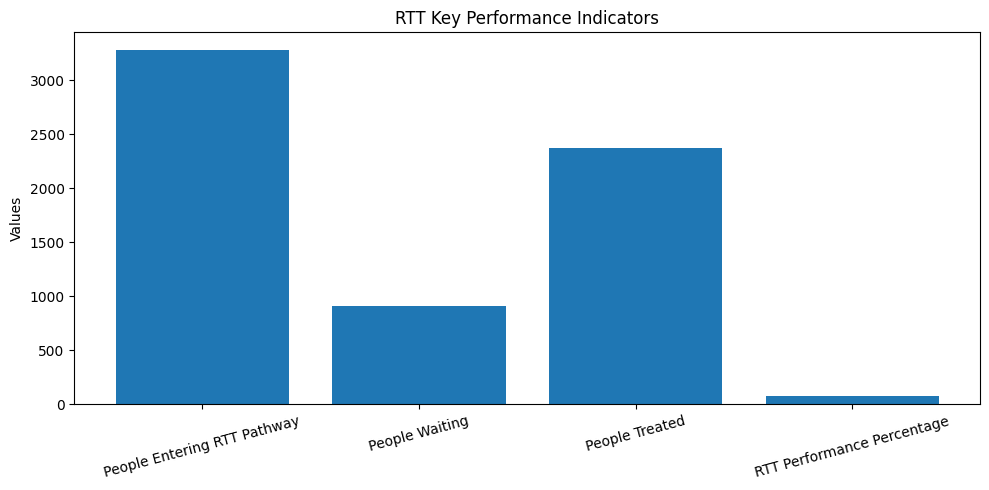

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    rtt_kpi["KPI"],
    rtt_kpi["Value"]
)

plt.xticks(rotation=15)

plt.title("RTT Key Performance Indicators")

plt.ylabel("Values")

plt.tight_layout()

plt.show()

# Percentage Visualization

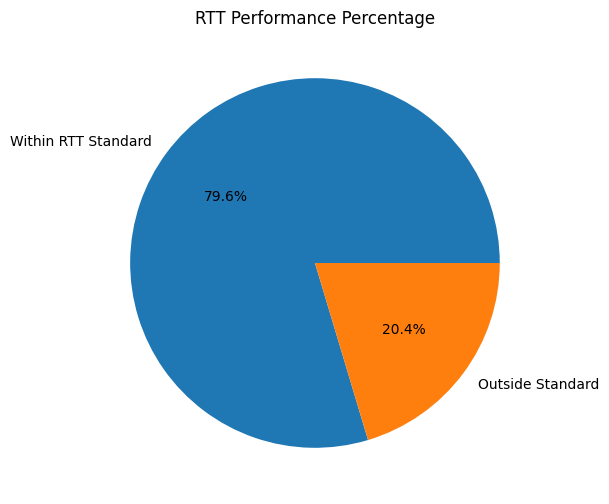

In [33]:
plt.figure(figsize=(6,6))

plt.pie(
    [england_2a["EIP23j"], 100-england_2a["EIP23j"]],
    labels=["Within RTT Standard", "Outside Standard"],
    autopct="%1.1f%%"
)

plt.title("RTT Performance Percentage")

plt.show()

In [34]:
rtt_kpi.to_csv(
    "RTT_KPI_Report.csv",
    index=False
)

# Source Mapping Table

In [35]:
source_mapping = pd.DataFrame({

    "KPI": [
        "Beds",
        "Contacts",
        "Crisis Calls",
        "Admissions",
        "RTT"
    ],

    "Source_File": [
        "MHSDS Data_MarPerf_2026_v2.csv",
        "MHSDS Data_MarPerf_2026_v2.csv",
        "MHSDS Data_MarPerf_2026_v2.csv",
        "MHSDS Data_MarPerf_2026_v2.csv",
        "RTT  waiting times.xlsx"
    ],

    "Column_Used": [
        "MEASURE_NAME + MEASURE_VALUE",
        "MEASURE_NAME + MEASURE_VALUE",
        "MEASURE_NAME + MEASURE_VALUE",
        "MEASURE_NAME + MEASURE_VALUE",
        "RTT waiting metrics"
    ]
})

display(source_mapping)

,KPI,Source_File,Column_Used
0,Beds,MHSDS Data_MarPerf_2026_v2.csv,MEASURE_NAME + MEASURE_VALUE
1,Contacts,MHSDS Data_MarPerf_2026_v2.csv,MEASURE_NAME + MEASURE_VALUE
2,Crisis Calls,MHSDS Data_MarPerf_2026_v2.csv,MEASURE_NAME + MEASURE_VALUE
3,Admissions,MHSDS Data_MarPerf_2026_v2.csv,MEASURE_NAME + MEASURE_VALUE
4,RTT,RTT waiting times.xlsx,RTT waiting metrics


In [36]:
final_kpi.to_csv(
    "MHSDS_Final_KPI_Table.csv",
    index=False
)

source_mapping.to_csv(
    "MHSDS_Source_Mapping.csv",
    index=False
)

print("Files saved successfully")

Files saved successfully
